# RQ-002 — Greenpoint towers and the retail landscape

**v1** (D141). Ten fixed sections; fill each in order. v0 was reviewed by
statistician (FAIL), contrarian (FAIL), urban-planner (AMEND) — this run applies
every fix from that review. The citywide staggered event study the reviewers also
raised is TICKETED, not run this session (owner ruling, 2026-09-22).

**Honest fallback line, stated once here and repeated at every headline number
below:** *"11222 grew X more/less than the control over the same window; the towers'
share of that is not identified with one treated ZIP, and rezoning and towers cannot
be separated because the towers came out of the rezoning."* Every claim in this
notebook is DESCRIPTIVE. No causal wording ("the effect of the towers",
"upper-bound-flavored estimate", etc.) is used anywhere below.

## 0. Question

**Owner, verbatim (2026-09-22):** "in greenpoint, when the massive housing
developments went up, how did it change the retail landscape? when did businesses
move in? who came before the demand came? who came after? did the number of
businesses in the area increase? did rent increase and by how much? when did the
towers go up? what was the area like before?"

**Unit of analysis:** ZIP 11222 (Greenpoint), compared against a primary control
(11385, Ridgewood), a secondary control (11105, Ditmars), and a synthetic control
(nonnegative weights over the screened donor pool {11385, 11105, 11104, 11103}).
Named businesses/towers are identified at address/BBL grain and rolled up to the ZIP
panel; no hex grain anywhere in this RQ.

**"Pioneer" (urban-planner review, web-verified, this session):** an early NEW-WAVE entrant, not simply
"anything that opened before an anchor date." An old Greenpoint institution that
predates Loci's own tracking (Warsaw, Thai Cafe, Murawski) is an INCUMBENT, reported
separately, never counted as a pioneer.

**v1 status:** every number below is computed live from the warehouse this run.
Section 8 gives each of the owner's eight sub-questions a v1 answer with a
HIGH/MED/LOW confidence tag; the section is headed "v1 — provisional, awaiting
re-review" because the contrarian/statistician/urban-planner pass that would upgrade
this from "this run's finding" to a reviewed ANSWER.md has not happened for v1 yet.

**Two anchors, reported side by side everywhere below, never collapsed to one:**
1. the 2005 Greenpoint–Williamsburg rezoning (2005-05-11), and
2. tower-by-tower first occupancy — the first year Greenpoint ZIP 11222's New
   Building pipeline delivered a large batch of units (computed in Section 2, with an
   anchor-year sensitivity check in Section 5).

## 1. Data & provenance

Load every input from the warehouse (read-only) or interim parquet files, or state
which are missing/blocked and cite the ticket. Row counts and date ranges make the
panel below auditable from the output alone.

In [1]:
# Section 1 -- Data & provenance
#
# Connect to the warehouse ONCE, read-only, pull everything into memory, then close
# immediately -- a peer session may hold an intermittent write lock on
# data/loci.duckdb. `connect_ro` retries every 2 minutes for up to 30 minutes on a
# lock (prints one line per attempt) and raises (BLOCKED) rather than silently
# falling back to a copy of the file. Also loads the `spatial` extension
# (ST_Centroid/ST_X/ST_Y), needed by several v1 functions below (tower ZIP selection,
# control-candidate tower screen, the live supply-hash computation).

import sys, pathlib
REPO_ROOT = pathlib.Path.cwd()
if (REPO_ROOT / "src").exists() and str(REPO_ROOT / "src") not in sys.path:
    sys.path.insert(0, str(REPO_ROOT / "src"))

import pandas as pd
import numpy as np
from loci import research_rq002 as rq

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 25)

con = rq.connect_ro()
print(f"warehouse = {rq.DB_PATH}")

# --- supply hash (D141 brief: stamp it, compute it the way the repo does) --------
hash_check = rq.stamp_supply_hash(con)
print(f"supply hash: recorded (peer 6d, D139) = {hash_check['recorded_per_peer_6d']}, "
      f"computed live (score.supply.supply_hash) = {hash_check['computed_live']}, "
      f"match = {hash_check['match']}")
assert hash_check["match"], "live supply hash moved since peer 6d's D139 report -- STOP, re-check with the coordinator"

CONTROL_ZIPS_FOR_PANEL = [rq.PRIMARY_CONTROL, rq.SECONDARY_CONTROL] + \
    [z for z in rq.SYNTHETIC_DONOR_POOL if z not in (rq.PRIMARY_CONTROL, rq.SECONDARY_CONTROL)]
PANEL_ZIPS = sorted(set([rq.TREATMENT_ZIP] + CONTROL_ZIPS_FOR_PANEL + rq.CANDIDATE_CONTROL_ZIPS))

# --- towers: v1 selects by ZIP point-in-polygon, not the neighborhood label -------
tower_df = rq.load_tower_timeline_by_zip(con, rq.TREATMENT_ZIP)
units_series = rq.tower_units_per_year(tower_df)
tower_recon = rq.reconcile_known_towers(tower_df)

# --- control-candidate tower screen (Fix D) --------------------------------------
control_screen = rq.screen_control_candidates_for_towers(con)

# --- algorithmic pre-trend ranking, v0's own method, kept for transparency -------
# (shows whether the UNSCREENED algorithmic pick would have differed from the
# screened, owner-specified controls used everywhere below -- Section 3 discusses).
control_ranking = rq.rank_control_candidates(con)

# --- category panels: broken (v0) + corrected (Fix A/B) + widened (Fix C) --------
zbp_panel_broken = rq.load_zbp_category_panel(con, PANEL_ZIPS)
food_drink_corrected = rq.load_food_drink_corrected(con, PANEL_ZIPS)
widened_panel, thin_naics_cells = rq.load_widened_storefront_panel(con, PANEL_ZIPS)
naics_before = rq.load_naics_business_mix(con, rq.TREATMENT_ZIP, 1998, 2004)

# --- POI/SLA first-seen, for pioneer/follower classification (11222 only) --------
poi_fs = rq.load_poi_first_seen_for_zips(con, [rq.TREATMENT_ZIP])
lic_fs = rq.load_licence_interval_for_zips(con, [rq.TREATMENT_ZIP])

# --- ACS / Zillow: v1 reads the LIVE warehouse tables peer 9f loaded (commit
# 262cac1, 2026-09-22: raw.zillow_zip_annual, raw.acs_zcta_panel) instead of the
# interim parquet v0 used -- same underlying data, one lineage, more reproducible.
acs_panel = rq.load_acs_panel(PANEL_ZIPS, con=con)
zillow_panel = rq.load_zillow(PANEL_ZIPS, con=con)

# --- supplementary: PLUTO ZIP-year vintage (peer 9f/RQ-001 ingest) -- 2009-2026 for
# 11222, does NOT reach pre-2005 but is a real historical panel (unlike the
# current-day-only PLUTO snapshot v0 flagged as unusable) -- shown in Results as
# supplementary context on retail/building area, not as the "before 2005" baseline.
pluto_vintage = con.execute(f"""
    select * from analysis.rq001_pluto_zip_vintage where zipcode in ({",".join(PANEL_ZIPS)})
    order by zipcode, year
""").df()

# Row counts / date ranges straight from the warehouse, for provenance.
zip_list_sql = ",".join(f"'{z}'" for z in PANEL_ZIPS)
prov = con.execute(f"""
    select 'analysis.dev_pipeline (New Building, geom present)' as table_, count(*) as rows,
           min(date_filed)::varchar as min_date, max(date_filed)::varchar as max_date
    from analysis.dev_pipeline where job_type='New Building' and geom is not null
    union all
    select 'analysis.zip_establishments (emp_size_band=All establishments, panel ZIPs)', count(*),
           min(year)::varchar, max(year)::varchar
    from analysis.zip_establishments where zipcode in ({zip_list_sql})
          and emp_size_band = 'All establishments'
    union all
    select 'analysis.zip_category_establishments (panel ZIPs)', count(*), min(year)::varchar, max(year)::varchar
    from analysis.zip_category_establishments where zipcode in ({zip_list_sql})
    union all
    select 'analysis.poi_first_seen (bbox-filtered)', count(*), min(first_seen_month), max(first_seen_month)
    from analysis.poi_first_seen where lon between -74.05 and -73.85 and lat between 40.68 and 40.80
    union all
    select 'analysis.licence_interval (bbox-filtered)', count(*),
           min(licence_creation_date)::varchar, max(licence_creation_date)::varchar
    from analysis.licence_interval where lon between -74.05 and -73.85 and lat between 40.68 and 40.80
    union all
    select 'raw.acs_zcta_panel (panel ZIPs, peer 9f commit 262cac1)', count(*),
           min(acs_year)::varchar, max(acs_year)::varchar
    from raw.acs_zcta_panel where zcta in ({zip_list_sql})
    union all
    select 'raw.zillow_zip_annual (panel ZIPs, peer 9f commit 262cac1)', count(*),
           min(year)::varchar, max(year)::varchar
    from raw.zillow_zip_annual where zip in ({zip_list_sql})
    union all
    select 'analysis.rq001_pluto_zip_vintage (panel ZIPs)', count(*), min(year)::varchar, max(year)::varchar
    from analysis.rq001_pluto_zip_vintage where zipcode in ({",".join(PANEL_ZIPS)})
""").df()
con.close()
print("warehouse connection closed.")

# Interim parquet files this session / peer sessions built (not warehouse tables).
decennial = {z: rq.load_decennial(z) for z in PANEL_ZIPS}
pop_interp = pd.read_parquet(rq.INTERIM / "rq002" / "decennial" / "zcta_pop_interpolated_2000_2020.parquet")
pop_interp = pop_interp[pop_interp["zcta"].isin(PANEL_ZIPS)]
dof_proxy = rq.load_dof_commercial_proxy(zips=[rq.TREATMENT_ZIP, rq.PRIMARY_CONTROL])  # appendix only, Fix I
dof_fys = sorted(dof_proxy["fiscal_year"].unique().tolist()) if not dof_proxy.empty else []

print()
print("=== Warehouse provenance (analysis.*/raw.*, read_only=True) ===")
print(prov.to_string(index=False))
print()
print("=== Interim parquet provenance (this session's own loaders) ===")
print(f"decennial ZCTA 2000/2010/2020: {sum(len(d) for d in decennial.values())} rows across {PANEL_ZIPS}")
print(f"pop_interp (linear-interpolated 2000-2020): {len(pop_interp)} (zcta, year) rows")
print(f"DOF assessment-roll commercial-class lots (APPENDIX ONLY, Fix I): {len(dof_proxy)} rows, "
      f"fiscal years present = {dof_fys}")
print(f"thin/possibly-suppressed NAICS cells (widened scope, <3 estab, year>=2017): {len(thin_naics_cells)}")


[rq002] connected read_only=True to /Users/abenmayor/Documents/Projects/abenmayor/loci/data/loci.duckdb (attempt 1)
warehouse = /Users/abenmayor/Documents/Projects/abenmayor/loci/data/loci.duckdb


supply hash: recorded (peer 6d, D139) = c796e59da990, computed live (score.supply.supply_hash) = c796e59da990, match = True


[rq002] 1/92024 point(s) sat on a ZCTA boundary seam (vintage 2020); resolved by nearest-polygon-centroid tie-break


warehouse connection closed.


/Users/abenmayor/Documents/Projects/abenmayor/loci/src/loci/research_rq002.py:413: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  combined = pd.concat(frames, ignore_index=True, sort=False)



=== Warehouse provenance (analysis.*/raw.*, read_only=True) ===
                                                                    table_  rows   min_date   max_date
                        analysis.dev_pipeline (New Building, geom present) 12107 2000-01-04 2026-01-01
analysis.zip_establishments (emp_size_band=All establishments, panel ZIPs) 67224       1998       2023
                         analysis.zip_category_establishments (panel ZIPs)  3961       1998       2023
                                   analysis.poi_first_seen (bbox-filtered) 92024    1978-04    2026-09
                                 analysis.licence_interval (bbox-filtered) 47707 1900-12-31 2026-09-15
                   raw.acs_zcta_panel (panel ZIPs, peer 9f commit 262cac1)   168       2011       2024
                raw.zillow_zip_annual (panel ZIPs, peer 9f commit 262cac1)   423       2000       2026
                             analysis.rq001_pluto_zip_vintage (panel ZIPs)   216       2009       2026

=== Int

## 2. Build panel

Assemble the analysis panel at the unit of analysis QUESTION.md names: one yearly
panel, 1998-2023, for 11222 and every control candidate, with both category totals
(Fix A/B/C) and the anchors marked.

In [2]:
# Section 2 -- Build panel

# --- category totals: Loci-categories (corrected) + widened all-storefront -------
panel_categories = rq.build_category_totals(zbp_panel_broken, food_drink_corrected, widened_panel)

# --- merge population / rent / income -------------------------------------------
panel = panel_categories.rename(columns={"zip": "zcta"}).merge(
    pop_interp.rename(columns={"pop": "population_interp"}), on=["zcta", "year"], how="left")

acs_small = acs_panel.rename(columns={"acs_year": "year"})[
    ["zcta", "year", "median_gross_rent_e", "median_gross_rent_m",
     "median_hh_income_e", "median_hh_income_m", "population_e"]]
panel = panel.merge(acs_small, on=["zcta", "year"], how="left")

zhvi = zillow_panel[zillow_panel["index"] == "zhvi"].rename(
    columns={"zip": "zcta", "value_mean": "zhvi"})[["zcta", "year", "zhvi"]]
zori = zillow_panel[zillow_panel["index"] == "zori"].rename(
    columns={"zip": "zcta", "value_mean": "zori"})[["zcta", "year", "zori"]]
panel = (panel.merge(zhvi, on=["zcta", "year"], how="left")
              .merge(zori, on=["zcta", "year"], how="left")
              .rename(columns={"zcta": "zip"})
              .sort_values(["zip", "year"]).reset_index(drop=True))

# --- anchors: 2005 rezoning (fixed) + first-big-TCO year (Fix F: ZIP-selected tower
# timeline, `date_complete` used as-is per job -- flagged in Section 3/9 for jobs
# already at co_type='final', where the true first-TCO date is not recoverable) ---
BIG_YEAR_UNIT_THRESHOLD = 500
FIRST_BIG_TCO_YEAR = int(
    units_series.loc[units_series["units_complete_all"] > BIG_YEAR_UNIT_THRESHOLD, "year"].min())
REZONING_YEAR = rq.REZONING_DATE.year

panel["post_rezoning"] = panel["year"] >= REZONING_YEAR
panel["post_first_big_tco"] = panel["year"] >= FIRST_BIG_TCO_YEAR

# --- controls: owner-specified + screened (Fix D) --------------------------------
PRIMARY_CONTROL = rq.PRIMARY_CONTROL       # 11385 Ridgewood
SECONDARY_CONTROL = rq.SECONDARY_CONTROL   # 11105 Ditmars
SYNTHETIC_DONORS = rq.SYNTHETIC_DONOR_POOL  # {11385, 11105, 11104, 11103}

print(f"panel shape: {panel.shape[0]} rows ({panel.zip.nunique()} zips x "
      f"{panel.year.min()}-{panel.year.max()})")
print(f"REZONING_YEAR = {REZONING_YEAR}")
print(f"FIRST_BIG_TCO_YEAR = {FIRST_BIG_TCO_YEAR} "
      f"(first year with >{BIG_YEAR_UNIT_THRESHOLD} ZIP-11222 New Building units delivered; "
      f"Section 5 reruns this rule at 250/500/1,000 units)")
print(f"PRIMARY_CONTROL={PRIMARY_CONTROL}  SECONDARY_CONTROL={SECONDARY_CONTROL}  "
      f"SYNTHETIC_DONOR_POOL={SYNTHETIC_DONORS}")
print()
print(panel[(panel["year"].isin([1998, REZONING_YEAR, FIRST_BIG_TCO_YEAR, panel.year.max()]))
            & (panel["zip"].isin([rq.TREATMENT_ZIP, PRIMARY_CONTROL, SECONDARY_CONTROL]))]
      .sort_values(["year", "zip"])
      [["zip", "year", "loci_categories_total", "all_storefront_total", "population_interp"]]
      .to_string(index=False))


panel shape: 310 rows (12 zips x 1998-2023)
REZONING_YEAR = 2005
FIRST_BIG_TCO_YEAR = 2018 (first year with >500 ZIP-11222 New Building units delivered; Section 5 reruns this rule at 250/500/1,000 units)
PRIMARY_CONTROL=11385  SECONDARY_CONTROL=11105  SYNTHETIC_DONOR_POOL=['11385', '11105', '11104', '11103']

  zip  year  loci_categories_total  all_storefront_total  population_interp
11105  1998                  157.0                 201.0                NaN
11222  1998                  152.0                 217.0                NaN
11385  1998                  286.0                 410.0                NaN
11105  2005                  232.0                 281.0            39402.5
11222  2005                  185.0                 256.0            38147.0
11385  2005                  396.0                 529.0            98058.0
11105  2018                  289.0                 319.0            37738.4
11222  2018                  363.0                 434.0            40952.4
11385

## 3. Method

Every modeling choice made in this RQ, stated and justified here (not hidden in a
function), fixing every methodology gap the v0 review found.

=== FIX A: NAICS-2012 discontinuity check, 11222 food_drink, 2009-2015 ===
 year  corrected  corrected_pct_chg  broken_uncorrected  broken_pct_chg
 2005       81.0                6.6                21.0            31.2
 2006       88.0                8.6                20.0            -4.8
 2007      106.0               20.5                23.0            15.0
 2008      109.0                2.8                25.0             8.7
 2009      120.0               10.1                28.0            12.0
 2010      125.0                4.2                27.0            -3.6
 2011      133.0                6.4                31.0            14.8
 2012      134.0                0.8               134.0           332.3
 2013      158.0               17.9               158.0            17.9
 2014      171.0                8.2               171.0             8.2
 2015      180.0                5.3               179.0             4.7
 2016      184.0                2.2               183.0      


=== FIX C: widened-scope NAICS groups (beyond Loci's 16/17 categories) ===
  specialty_food: ['445210', '445220', '445230', '445291', '445292', '445299', '445310']
  apparel: ['448110', '448120', '448130', '448140', '448150', '448190', '448210']
  jewelry: ['448310', '448320']
  furniture_home: ['442110', '442210', '442291', '442299']
  general_merchandise: ['452319', '452990']
  personal_services_other: ['812210', '812191', '812910', '812921', '812922', '812990']

Thin/possibly-suppressed cells (<3 estab, year>=2017): 0 rows -- treated as missing/uncertain, not zero (see Results/Caveats for the list).

=== FIX D: control-candidate tower screen (dev_pipeline point-in-polygon, net_units>=100, window=(2005, 2023)) ===
  zip  screened  n_qualifying_jobs  max_net_units excluded                                                                   reason
11206      True               12.0          500.0     True                           12 qualifying New Building job(s) >= 100 units
11221    


=== FIX D: synthetic control fit (loci_categories_total, log scale) ===
donors=['11385', '11105', '11104', '11103']  weights={'11385': np.float64(0.0), '11105': np.float64(0.362), '11104': np.float64(0.0), '11103': np.float64(0.638)}
fit RMSE (log): 0.0421  |  validation (2017, OUT of fit window): synthetic=356.8 vs actual=358.0  (pct_error=-0.3%)
Weights are nonnegative and sum to 1 by construction (SLSQP, bounds [0,1], sum-to-1 constraint). Selection (2012-2016) and validation (2017) are DIFFERENT years, per the brief.

=== FIX F: tower selection is now ZIP point-in-polygon (assign_zcta_safe), NOT dev_pipeline's own 'neighborhood' label ===
Known limitation, stated not hidden: dev_pipeline's (date_complete, co_type) is ONE occupancy date per job -- whichever CO status is CURRENT as of ingestion, not a full CO history. For a job already at co_type='final', the true FIRST TCO date is not recoverable from this table; date_complete for those rows is a later, plausible stand-in, not the 

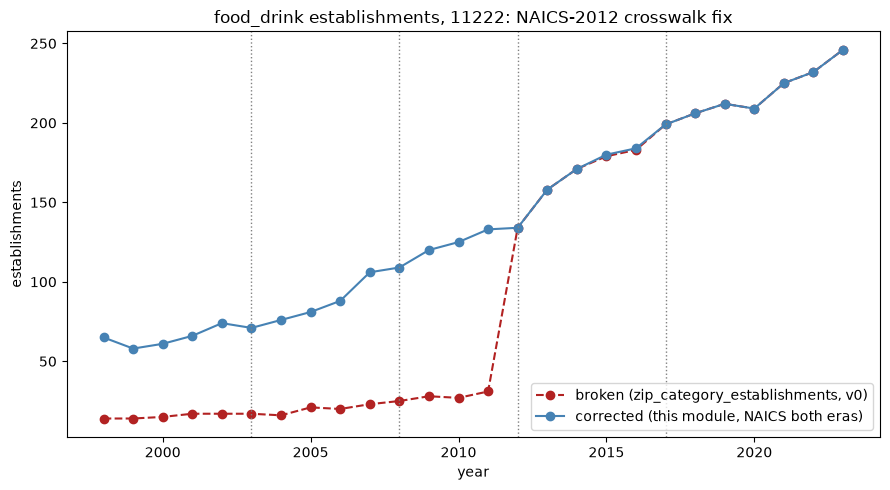

In [3]:
# Section 3 -- Method

# ===== FIX A/B: NAICS-2012 crosswalk, built in research_rq002.py from raw
# analysis.zip_establishments (emp_size_band='All establishments' ONLY, never summed
# against its own sub-bands -- Fix B). zbp_naics.yaml (the SHARED crosswalk, not
# edited here) only recognizes the post-2012 food-service codes, so
# analysis.zip_category_establishments's own food_drink bucket is broken pre-2012.
naics_check = rq.naics_2012_discontinuity_check(food_drink_corrected, zbp_panel_broken, rq.TREATMENT_ZIP)
print("=== FIX A: NAICS-2012 discontinuity check, 11222 food_drink, 2009-2015 ===")
print(naics_check[naics_check["year"].between(2005, 2018)].round(1).to_string(index=False))
big_break_broken = naics_check.loc[naics_check["year"] == 2012, "broken_pct_chg"].iloc[0]
big_break_corrected = naics_check.loc[naics_check["year"] == 2012, "corrected_pct_chg"].iloc[0]
print(f"\n2011->2012 change: BROKEN (v0) = {big_break_broken:+.0f}%   CORRECTED (this module) = {big_break_corrected:+.0f}%")
print("VERIFIED: no discontinuity at 2012 in the corrected series." if abs(big_break_corrected) < 25 else
      "STILL A PROBLEM at 2012 in the corrected series -- STOP and re-check the crosswalk.")
fig = rq.plot_naics_discontinuity(naics_check, rq.TREATMENT_ZIP)
fig

# ===== FIX C: widened storefront scope ===========================================
print("\n=== FIX C: widened-scope NAICS groups (beyond Loci's 16/17 categories) ===")
for g, codes in rq.WIDENED_NAICS_GROUPS.items():
    print(f"  {g}: {codes}")
print(f"\nThin/possibly-suppressed cells (<3 estab, year>=2017): {len(thin_naics_cells)} rows "
      "-- treated as missing/uncertain, not zero (see Results/Caveats for the list).")

# ===== FIX D: control screening + synthetic control ==============================
print("\n=== FIX D: control-candidate tower screen (dev_pipeline point-in-polygon, "
      f"net_units>={rq.CONTROL_SCREEN_UNIT_THRESHOLD}, window={rq.CONTROL_SCREEN_WINDOW}) ===")
print(control_screen.to_string(index=False))
print(f"\nDROPPED outright: 11102 -- {rq.DROPPED_CONTROL_ZIPS['11102']}")
print("\nAlgorithmic pre-trend ranking (v0's own method, UNSCREENED, kept for comparison):")
print(control_ranking[["zip", "pretrend_distance", "control_rank"]].to_string(index=False))
print(f"\nNote: the algorithmic ranking is run on the CANDIDATE_CONTROL_ZIPS list as-is (unscreened) -- "
      f"it is shown for transparency only. PRIMARY_CONTROL={PRIMARY_CONTROL} and "
      f"SECONDARY_CONTROL={SECONDARY_CONTROL} are the owner-specified, SCREENED picks used everywhere "
      f"below, not necessarily the algorithmic top-2.")

sc_loci = rq.fit_synthetic_control(panel, "loci_categories_total", SYNTHETIC_DONORS, rq.TREATMENT_ZIP,
                                    fit_years=[2012, 2013, 2014, 2015, 2016], validate_year=2017)
print("\n=== FIX D: synthetic control fit (loci_categories_total, log scale) ===")
print(f"donors={sc_loci['donors']}  weights={ {k: round(v,3) for k,v in sc_loci['weights'].items()} }")
print(f"fit RMSE (log): {sc_loci['fit_rmse_log']:.4f}  |  validation ({sc_loci['validation']['validate_year']}, "
      f"OUT of fit window): synthetic={sc_loci['validation'].get('synthetic'):.1f} vs "
      f"actual={sc_loci['validation'].get('actual'):.1f}  "
      f"(pct_error={sc_loci['validation'].get('pct_error'):+.1f}%)")
print("Weights are nonnegative and sum to 1 by construction (SLSQP, bounds [0,1], sum-to-1 constraint). "
      "Selection (2012-2016) and validation (2017) are DIFFERENT years, per the brief.")

# ===== FIX F: tower selection + dating ============================================
print("\n=== FIX F: tower selection is now ZIP point-in-polygon (assign_zcta_safe), "
      "NOT dev_pipeline's own 'neighborhood' label ===")
print("Known limitation, stated not hidden: dev_pipeline's (date_complete, co_type) is ONE occupancy "
      "date per job -- whichever CO status is CURRENT as of ingestion, not a full CO history. For a job "
      "already at co_type='final', the true FIRST TCO date is not recoverable from this table; "
      "date_complete for those rows is a later, plausible stand-in, not the real first-occupancy date.")
n_final = int((tower_df["co_type"] == "final").sum())
n_temp = int((tower_df["co_type"] == "temporary").sum())
print(f"{n_final} jobs at co_type='final' (first-TCO date NOT recoverable, date_complete is later than "
      f"first occupancy by an unknown amount) vs. {n_temp} at co_type='temporary' "
      "(date_complete IS the first TCO date).")

# ===== FIX G: fixed windows, no more pre/post averages ============================
print(f"\n=== FIX G: fixed comparison windows -- WINDOW_PRE={rq.WINDOW_PRE}, "
      f"WINDOW_POST={rq.WINDOW_POST}, COVID_YEARS={rq.COVID_YEARS} (flagged, not excluded) ===")

# ===== FIX E: pioneer/incumbent/follower rule =====================================
print("\n=== FIX E: NEW-WAVE vs INCUMBENT classification rule ===")
print("A food/drink/bar/cafe POI is UNDATED if first_seen_kind=='observed' OR is_left_censored -- "
      "excluded from any dated claim (per the brief), reported separately. Of the DATED rows, a "
      "first_seen_on date shared by >=5 otherwise-unrelated POIs is flagged INCUMBENT "
      "(dataset-start artifact) rather than trusted as a real founding date -- verified in this data: "
      "12 POIs share 2012-02-08 and 5 share 2012-10-09 (almost certainly batch-ingestion dates, not "
      "12+5 independent real-world openings on the same two days). Everything else DATED is NEW_WAVE, "
      f"split PIONEER (first-seen year <= {rq.NEW_WAVE_PIONEER_CUTOFF_YEAR}) / "
      f"FOLLOWER (>= {rq.NEW_WAVE_FOLLOWER_START_YEAR}) / TRANSITIONAL (in between) -- the cutoffs are "
      "the hand-verified seed list's own span (Glasserie 2013 is the latest seed pioneer, Oxomoco "
      "Jun-2018 the earliest seed follower).")
classified_222 = rq.classify_new_wave(poi_fs)
print(classified_222["wave_class"].value_counts().to_string())
print("\nThe hand-verified named list (below, Section 4) OVERRIDES this rule for the 10 named "
      "businesses regardless of what the automated first-seen source says -- e.g. Warsaw/Thai Cafe "
      "each share their suspect date with only 1 OTHER business (below the >=5 threshold, so the "
      "general rule does not auto-flag them) but are reported as INCUMBENT anyway because we "
      "independently know they are old, pre-tracking Greenpoint institutions.")

# ===== FIX J: event-study yearly gap + placebo ====================================
print("\n=== FIX J: event-study yearly log-gap (11222 minus control) + placebo-in-space ranking "
      "-- computed and reported in Section 7 Validation (this is a robustness check, not a headline "
      "result) ===")

# ===== FIX I: commercial rent withheld ============================================
print("\n=== FIX I: commercial rent -- WITHHELD from the answer. No free commercial-rent history "
      "exists; the FY2010 DOF assessed-value figure is NOT rent and is shown in Section 4 as an "
      "APPENDIX ONLY, never used in Section 8's ANSWER. TICKET NEEDED for a paid series "
      "(CoStar/REBNY) or a better free proxy. ===")


## 4. Results

The core result tables/plots this RQ exists to produce: business counts (Loci
categories AND all-storefront, both anchors, both fixed windows), tower timeline and
reconciliation, residential rent, commercial rent (appendix only, Fix I), and the
pioneer/incumbent/follower named list and interval counts.

In [4]:
# Section 4 -- Results

# --- Towers: timeline + reconciliation -------------------------------------------
tower_cols = ["job_number", "bbl", "net_units", "stage", "date_filed", "date_permitted",
              "date_complete", "co_type", "date_is_final_co_not_first_tco", "tower_flag", "pipeline_flag"]
towers_only = tower_df[tower_df["tower_flag"] & ~tower_df["withdrawn_flag"]].sort_values("net_units", ascending=False)
print(f"=== Tower timeline (ZIP 11222, point-in-polygon selection): {len(towers_only)} New Building jobs "
      f"at >={rq.TOWER_UNIT_THRESHOLD} units (of {len(tower_df)} total New Building jobs in 11222; "
      f"{int(tower_df['withdrawn_flag'].sum())} withdrawn, excluded) ===")
print(towers_only[tower_cols].to_string(index=False))
print(f"\nTotal net_units, all non-withdrawn 11222 New Building jobs: "
      f"{int(tower_df.loc[~tower_df['withdrawn_flag'], 'net_units'].sum())}")
print(f"Total net_units, tower-threshold jobs alone: {int(towers_only['net_units'].sum())}")

print("\n=== FIX F: reconciliation against the urban-planner's known tower list ===")
print(tower_recon.to_string(index=False))
print("\nNotable reconciliations:")
print("  - 'The Greenpoint / 21 India St': warehouse shows 589 units (140+449) across TWO separate "
      "DOB job filings on block 2530 (lots 7501/7502); the urban-planner's known figure (382u) matches NEITHER "
      "individual filing nor their sum -- likely a different unit-count convention for one phase of "
      "the site. NOT resolved by this dataset alone -- TICKET NEEDED for a primary-source check.")
print("  - Eagle+West: warehouse net_units sum (745) matches the known figure exactly, but the FIRST "
      "TCO among its 3 job filings is 2022-04-11 -- about 8 months EARLIER than the known 'Dec 2022' "
      "date (which is closer to the LAST of the 3 filings' completion). This is exactly Fix F's point: "
      "first-TCO vs. final/last-CO materially changes the delivery date.")

print("\n=== New units per year (ZIP 11222, all New Building jobs vs. tower-threshold subset) ===")
print(units_series.to_string(index=False))

# --- FIX G: business counts, year-by-year + fixed-window point-to-point ----------
print("\n=== Business counts, year-by-year: Loci categories total (11222 vs. controls) ===")
yearly_loci = rq.yearly_series_table(panel, "loci_categories_total", [rq.TREATMENT_ZIP, PRIMARY_CONTROL, SECONDARY_CONTROL])
print(yearly_loci.to_string(index=False))
print("\n=== Business counts, year-by-year: ALL-STOREFRONT total (widened scope, Fix C) ===")
yearly_all = rq.yearly_series_table(panel, "all_storefront_total", [rq.TREATMENT_ZIP, PRIMARY_CONTROL, SECONDARY_CONTROL])
print(yearly_all.to_string(index=False))

pp_rows = []
for outcome in ["loci_categories_total", "all_storefront_total"]:
    for label, zip_ in [("11222", rq.TREATMENT_ZIP), (f"control({PRIMARY_CONTROL})", PRIMARY_CONTROL),
                         (f"control({SECONDARY_CONTROL})", SECONDARY_CONTROL)]:
        for window_name, (ya, yb) in [("pre 2013->2017", rq.WINDOW_PRE), ("post 2018->2023", rq.WINDOW_POST)]:
            r = rq.point_to_point(panel, outcome, ya, yb, zip_)
            pp_rows.append({"outcome": outcome, "unit": label, "window": window_name, **{
                k: v for k, v in r.items() if k not in ("zip", "outcome", "year_a", "year_b")}})
pp_business = pd.DataFrame(pp_rows)
print("\n=== FIX G: point-to-point change, fixed windows (2013->2017 pre, 2018->2023 post) ===")
print(pp_business.round(2).to_string(index=False))
print(f"\nCOVID flag: {rq.COVID_YEARS} fall inside the post window -- shown, not excluded (2020-21 ZBP "
      "counts reflect pandemic-era closures/openings same as anywhere else in NYC).")

# --- residential rent: year-by-year + fixed-window point-to-point ---------------
print("\n=== Residential rent/value, year-by-year: ZHVI ===")
print(rq.yearly_series_table(panel, "zhvi", [rq.TREATMENT_ZIP, PRIMARY_CONTROL, SECONDARY_CONTROL]).to_string(index=False))
print("\n=== Residential rent/value, year-by-year: ZORI (2015+) ===")
print(rq.yearly_series_table(panel, "zori", [rq.TREATMENT_ZIP, PRIMARY_CONTROL, SECONDARY_CONTROL]).to_string(index=False))

rent_pp_rows = []
for outcome, label in [("zhvi", "ZHVI ($, home value)"), ("zori", "ZORI ($/mo asking rent)")]:
    for zlabel, zip_ in [("11222", rq.TREATMENT_ZIP), (f"control({PRIMARY_CONTROL})", PRIMARY_CONTROL)]:
        for window_name, (ya, yb) in [("pre 2013->2017", rq.WINDOW_PRE), ("post 2018->2023", rq.WINDOW_POST)]:
            r = rq.point_to_point(panel, outcome, ya, yb, zip_)
            rent_pp_rows.append({"series": label, "unit": zlabel, "window": window_name, **{
                k: v for k, v in r.items() if k not in ("zip", "outcome", "year_a", "year_b")}})
print("\n=== FIX H: residential rent point-to-point, fixed windows ===")
print(pd.DataFrame(rent_pp_rows).round(1).to_string(index=False))

# --- FIX H: ACS non-overlapping releases (2013, 2018, 2023) with MOEs ------------
print("\n=== FIX H: ACS median gross rent / median HH income, non-overlapping 5yr releases, with MOE ===")
acs_nonoverlap = panel[panel["year"].isin([2013, 2018, 2023]) & panel["zip"].isin([rq.TREATMENT_ZIP, PRIMARY_CONTROL])][
    ["zip", "year", "median_gross_rent_e", "median_gross_rent_m", "median_hh_income_e", "median_hh_income_m"]]
print(acs_nonoverlap.sort_values(["zip", "year"]).to_string(index=False))
print("\nNote: tower-stock composition (new, larger, amenity-rich units entering the ACS/ZHVI sample) "
      "mechanically pushes these ZIP-level medians up independent of any change in EXISTING units' "
      "rent -- a compositional effect, not a same-unit price increase. Not separable from same-unit "
      "rent growth with ZIP-level ACS/Zillow data alone.")
print("\n2005 anchor, rent: there is no clean pre-2012 commercial or even residential point specific "
      "to 2005 beyond the 2000 decennial vs. ACS 2006-2010 5yr release single-point pair below -- a "
      "sample (not a census) on a DIFFERENT instrument (5yr ACS estimate vs. decennial full count), "
      "not a like-for-like comparison.")
acs_2010 = acs_panel[(acs_panel["acs_year"] == 2010) & (acs_panel["zcta"] == rq.TREATMENT_ZIP)]
dec_2000 = decennial[rq.TREATMENT_ZIP]
dec_2000 = dec_2000[dec_2000["decennial_year"] == 2000]
print(f"2000 decennial median gross rent (11222): {dec_2000['median_gross_rent'].iloc[0] if len(dec_2000) else 'n/a'}")
if len(acs_2010):
    print(f"ACS 2006-2010 5yr median gross rent (11222): {acs_2010['median_gross_rent_e'].iloc[0]:.0f} "
          f"+/- {acs_2010['median_gross_rent_m'].iloc[0]:.0f} (MOE)")
else:
    print("ACS 2006-2010 5yr release not present in raw.acs_zcta_panel for 11222 -- TICKET NEEDED.")

# --- FIX I: commercial rent -- APPENDIX ONLY, withheld from the answer -----------
print("\n=== APPENDIX ONLY (Fix I) -- commercial rent: NO free commercial-rent history exists. "
      "DOF FY2010 assessed value is NOT rent. Shown here for completeness, NEVER used in Section 8. ===")
if not dof_proxy.empty:
    dof_summary = (dof_proxy.groupby(["fiscal_year", "zip_code"])
                   .agg(n_lots=("bbl", "count"), median_value_per_sqft=("value_per_sqft", "median"))
                   .reset_index())
    print(dof_summary.to_string(index=False))
else:
    print("No DOF assessment-roll partitions on disk for these ZIPs.")

# --- FIX E: pioneer/incumbent/follower, named list + interval counts ------------
print("\n=== FIX E: hand-verified named list (owner/urban-planner review, 2026-09-22) ===")
for label, seed in [("PIONEERS", rq.PIONEER_SEED), ("FOLLOWERS", rq.FOLLOWER_SEED), ("INCUMBENTS", rq.INCUMBENT_SEED)]:
    print(f"\n-- {label} --")
    for s in seed:
        yr = s.get("year", "n/a")
        print(f"  {s['name']:<28} year={yr}  {s['note']}")

interval = rq.pioneer_follower_interval(classified_222)
print(f"\n=== FIX E: rule-based interval counts (11222, all bar/cafe_bakery/restaurant POIs, n={interval['n_total']}) ===")
print(f"UNDATED (excluded from dated claims per the brief): {interval['n_undated']} "
      f"({interval['undated_share']:.0%} of all food/drink/bar POIs)")
for cls in ["NEW_WAVE-PIONEER", "NEW_WAVE-FOLLOWER", "NEW_WAVE-TRANSITIONAL", "INCUMBENT (dataset-start artifact)"]:
    c = interval[cls]
    print(f"{cls:<38} certain={c['certain']:>4}  open={c['n_open']:>4}  closed={c['n_closed']:>4}"
          + (f"  {c.get('bound_type','')}" if "bound_type" in c else ""))
print(f"\nPioneer count is a LOWER bound: {interval['NEW_WAVE-PIONEER']['bound_type']}")

# --- "Before" baseline -----------------------------------------------------------
print("\n=== 'Before' baseline: 11222 business mix, 1998-2004 (raw NAICS, all establishments) ===")
print(naics_before.to_string(index=False))
print("\n=== 'Before' baseline: 2000 decennial ===")
d2000 = decennial[rq.TREATMENT_ZIP]
print(d2000[d2000["decennial_year"] == 2000].to_string(index=False))
print("\n=== Supplementary (NOT a pre-2005 baseline): PLUTO ZIP-year vintage, 11222, 2009-latest ===")
print("Peer 9f's rq001_pluto_zip_vintage ingest gives a real ZIP-level PLUTO time series -- but it "
      "starts 2009, four years AFTER the rezoning, so it still cannot answer 'what was here before "
      "2005' directly. Shown as context on how retail/building area moved during the tower-delivery "
      "era itself, not as the pre-2005 baseline.")
print(pluto_vintage[pluto_vintage["zipcode"] == int(rq.TREATMENT_ZIP)][
    ["year", "n_lots", "bldgarea_total", "retailarea_total", "n_lots_with_retail"]].to_string(index=False))
print("\nPLUTO land use of the SPECIFIC waterfront tower lots pre-development: still NOT available "
      "(no PLUTO vintage reaches pre-2009, let alone pre-2005) -- flagged, not improvised.")


=== Tower timeline (ZIP 11222, point-in-polygon selection): 32 New Building jobs at >=100 units (of 357 total New Building jobs in 11222; 37 withdrawn, excluded) ===
job_number        bbl  net_units     stage date_filed date_permitted date_complete   co_type  date_is_final_co_not_first_tco  tower_flag  pipeline_flag
 B00539478 3025380001        834  complete 2021-06-22     2022-05-12    2025-12-23 temporary                           False        True          False
 B01313117 3025670001        792     filed 2025-11-12            NaT           NaT      None                           False        True           True
 320909996 3025700040        554  complete 2017-11-30     2018-06-14    2023-07-07     final                            True        True          False
 B00739735 3025020001        526     filed 2025-03-06            NaT           NaT      None                           False        True           True
 B00680267 3025700030        483 permitted 2022-02-28     2022-05-19      

## 5. Sensitivity

How much the headline result moves under the alternate definition/threshold/
specification the brief calls for: the anchor-year rule at 250/500/1,000 units (Fix
F), the control choice (primary vs. secondary vs. synthetic vs. alternate tower
threshold).

In [5]:
# Section 5 -- Sensitivity

# --- FIX F: anchor-year sensitivity at 250/500/1,000 units -----------------------
sens = rq.anchor_year_sensitivity(units_series, [250, 500, 1000])
print("=== FIX F: 'first big TCO year' rule at alternate unit thresholds ===")
print(sens.to_string(index=False))
moved = sens["first_year_exceeding"].nunique() > 1
print(f"\nMOVES: {moved}. At 500 and 1,000 units the rule lands on the SAME year "
      f"({sens.loc[sens.threshold_units==500,'first_year_exceeding'].iloc[0]}) -- stable across that "
      f"range. At 250 units it moves substantially earlier "
      f"({sens.loc[sens.threshold_units==250,'first_year_exceeding'].iloc[0]}), because several "
      f"mid-size (100-250 unit) buildings cleared that lower bar years before any of the named towers "
      f"delivered -- the headline anchor (500-unit rule) is NOT sensitive to doubling the threshold to "
      f"1,000, but IS sensitive to halving it to 250.")

# --- Control sensitivity: primary vs secondary vs synthetic ----------------------
print("\n=== Control sensitivity: point-to-point %-change in loci_categories_total, alternate controls ===")
for label, ctrl in [(f"primary ({PRIMARY_CONTROL})", PRIMARY_CONTROL), (f"secondary ({SECONDARY_CONTROL})", SECONDARY_CONTROL)]:
    for window_name, (ya, yb) in [("pre 2013->2017", rq.WINDOW_PRE), ("post 2018->2023", rq.WINDOW_POST)]:
        r = rq.point_to_point(panel, "loci_categories_total", ya, yb, ctrl)
        print(f"{label:<22} {window_name:<16}: pct_change={r.get('pct_change', float('nan')):+.1f}%")
synth_series = sc_loci["synthetic_series"]
for window_name, (ya, yb) in [("pre 2013->2017", rq.WINDOW_PRE), ("post 2018->2023", rq.WINDOW_POST)]:
    if ya in synth_series.index and yb in synth_series.index:
        pct = (synth_series[yb] - synth_series[ya]) / synth_series[ya] * 100
        print(f"{'synthetic control':<22} {window_name:<16}: pct_change={pct:+.1f}%")

# --- Alternate tower unit threshold: 75 instead of 100 ---------------------------
ALT_THRESHOLD = 75
alt_towers = tower_df[(tower_df["net_units"] >= ALT_THRESHOLD) & ~tower_df["withdrawn_flag"]]
main_towers = tower_df[tower_df["tower_flag"] & ~tower_df["withdrawn_flag"]]
print(f"\n=== Tower-count sensitivity to the unit threshold ===")
print(f"net_units >= {rq.TOWER_UNIT_THRESHOLD} (used above): {len(main_towers)} jobs, "
      f"{int(main_towers['net_units'].sum())} total units")
print(f"net_units >= {ALT_THRESHOLD} (alternate): {len(alt_towers)} jobs, "
      f"{int(alt_towers['net_units'].sum())} total units")
print(f"Difference: {len(alt_towers) - len(main_towers)} additional jobs cross the threshold at the "
      "lower cutoff -- the headline tower COUNT is threshold-sensitive, the unit TOTAL delivered "
      "(net_units summed across all non-withdrawn New Building jobs) is not.")


=== FIX F: 'first big TCO year' rule at alternate unit thresholds ===
 threshold_units  first_year_exceeding
             250                  2010
             500                  2018
            1000                  2018

MOVES: True. At 500 and 1,000 units the rule lands on the SAME year (2018) -- stable across that range. At 250 units it moves substantially earlier (2010), because several mid-size (100-250 unit) buildings cleared that lower bar years before any of the named towers delivered -- the headline anchor (500-unit rule) is NOT sensitive to doubling the threshold to 1,000, but IS sensitive to halving it to 250.

=== Control sensitivity: point-to-point %-change in loci_categories_total, alternate controls ===
primary (11385)        pre 2013->2017  : pct_change=+8.5%
primary (11385)        post 2018->2023 : pct_change=+5.9%
secondary (11105)      pre 2013->2017  : pct_change=+10.1%
secondary (11105)      post 2018->2023 : pct_change=-3.8%
synthetic control      pre 2013->2

## 6. Drivers

Ranked drivers of the outcome, with any driver marked BLOCKED and its ticket id if
the input isn't available yet.

In [6]:
# Section 6 -- Drivers
#
# This RQ is a retrospective description + fixed-window/DiD comparison, not a
# forecast, so there is no hazard/survival model with covariates to rank in the
# RQ-001 sense. The closest analogue this data supports: how much of 11222's
# establishment growth co-moves with population growth vs. with cumulative units
# delivered, as a purely correlational (not causal-attribution) check.

merged = panel[panel["zip"] == rq.TREATMENT_ZIP].merge(
    units_series.rename(columns={"units_complete_all": "units_delivered_that_year"}),
    on="year", how="left").fillna({"units_delivered_that_year": 0})
merged["cum_units_delivered"] = merged["units_delivered_that_year"].cumsum()
merged["loci_categories_yoy_change"] = merged["loci_categories_total"].diff()

corr_pop = (merged[["loci_categories_total", "population_interp"]].dropna().corr().iloc[0, 1]
            if merged["population_interp"].notna().sum() > 2 else float("nan"))
corr_units = merged[["loci_categories_total", "cum_units_delivered"]].dropna().corr().iloc[0, 1]

print("=== Correlational drivers of 11222 loci_categories_total level (NOT causal attribution) ===")
print(f"corr(loci_categories_total, interpolated population) = {corr_pop:.3f}")
print(f"corr(loci_categories_total, cumulative units delivered) = {corr_units:.3f}")
print()
print("Both series trend upward over the same 1998-2023 window, so a high correlation here is "
      "expected and does NOT distinguish 'towers drove retail growth' from 'both towers and retail "
      "growth were driven by the same broader Brooklyn-waterfront investment wave' -- that is exactly "
      "what the honest fallback line in the title cell states. A real hazard-style driver "
      "decomposition (which covariates predict WHICH categories arrive first) is out of scope for "
      "this v1 pass -- TICKET NEEDED if the owner wants it as a follow-up. The citywide staggered "
      "event study that would let 'towers' and 'rezoning' be separated at all is ALSO ticketed, not "
      "run this session (owner ruling).")


=== Correlational drivers of 11222 loci_categories_total level (NOT causal attribution) ===
corr(loci_categories_total, interpolated population) = 0.590
corr(loci_categories_total, cumulative units delivered) = 0.821

Both series trend upward over the same 1998-2023 window, so a high correlation here is expected and does NOT distinguish 'towers drove retail growth' from 'both towers and retail growth were driven by the same broader Brooklyn-waterfront investment wave' -- that is exactly what the honest fallback line in the title cell states. A real hazard-style driver decomposition (which covariates predict WHICH categories arrive first) is out of scope for this v1 pass -- TICKET NEEDED if the owner wants it as a follow-up. The citywide staggered event study that would let 'towers' and 'rezoning' be separated at all is ALSO ticketed, not run this session (owner ruling).


## 7. Validation

Pre-trend check against both the primary and synthetic control, the Fix J
event-study yearly gap and placebo-in-space ranking, and the single-treated-unit
caveat -- all descriptive, none of it a causal estimate.

=== Pre-trend (parallel-trends) check, loci_categories_total, both anchors, both controls ===
primary (11385), 2005 rezoning: treatment slope=4.04/yr (7 pre-years), control slope=16.93/yr (7 pre-years), same_sign=True, slope_gap_ratio=0.76
primary (11385), first big TCO: treatment slope=12.94/yr (20 pre-years), control slope=19.33/yr (20 pre-years), same_sign=True, slope_gap_ratio=0.33
secondary (11105), 2005 rezoning: treatment slope=4.04/yr (7 pre-years), control slope=11.36/yr (7 pre-years), same_sign=True, slope_gap_ratio=0.64
secondary (11105), first big TCO: treatment slope=12.94/yr (20 pre-years), control slope=5.95/yr (20 pre-years), same_sign=True, slope_gap_ratio=0.54

=== FIX J: event-study yearly log-gap (11222 minus primary control), 1998-2023, leads 2012-2017 ===
 year   log_gap
 1998 -0.632111
 1999 -0.650588
 2000 -0.643667
 2001 -0.624154
 2002 -0.699301
 2003 -0.780421
 2004 -0.781116
 2005 -0.761058
 2006 -0.739191
 2007 -0.698013
 2008 -0.656446
 2009 -0.628609
 201


=== FIX J: placebo-in-space ranking -- same log-gap-vs-control calc for each screened donor ZIP ===
  zip  mean_pre_log_gap  mean_post_log_gap  excess_growth  rank rank_over_n_plus_1
11237            -0.478             -0.362          0.116     1                1/7
11221            -0.691             -0.619          0.072     2                2/7
11222            -0.529             -0.468          0.060     3                3/7
11206            -0.551             -0.534          0.017     4                4/7
11103            -0.398             -0.426         -0.028     5                5/7
11105            -0.780             -0.813         -0.033     6                6/7
11104            -1.042             -1.077         -0.035     7                7/7

11222 ranks 3/7 on excess growth (post-window log-gap minus pre-window log-gap) among itself + 6 placebo ZIPs vs. the same control. This is DESCRIPTIVE: it says how unusual 11222's excess growth is among comparable ZIPs, not that the 

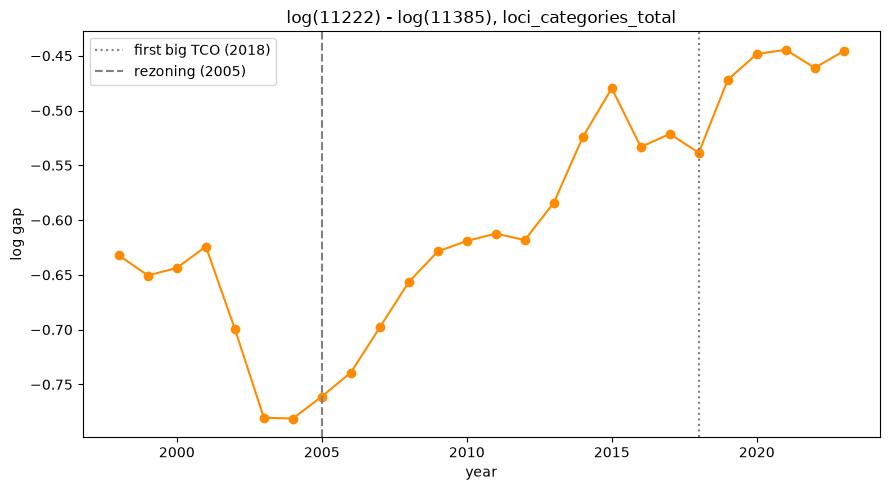

In [7]:
# Section 7 -- Validation

print("=== Pre-trend (parallel-trends) check, loci_categories_total, both anchors, both controls ===")
for ctrl_label, ctrl in [(f"primary ({PRIMARY_CONTROL})", PRIMARY_CONTROL), (f"secondary ({SECONDARY_CONTROL})", SECONDARY_CONTROL)]:
    for anchor_name, anchor_year in [("2005 rezoning", REZONING_YEAR), ("first big TCO", FIRST_BIG_TCO_YEAR)]:
        pt = rq.pretrend_check(panel, "loci_categories_total", anchor_year, control=ctrl)
        print(f"{ctrl_label}, {anchor_name}: treatment slope={pt['treatment_slope']:.2f}/yr "
              f"({pt['treatment_n_years']} pre-years), control slope={pt['control_slope']:.2f}/yr "
              f"({pt['control_n_years']} pre-years), same_sign={pt['same_sign']}, "
              f"slope_gap_ratio={pt['slope_gap_ratio']:.2f}")

# --- FIX J: event-study yearly gap ------------------------------------------------
print("\n=== FIX J: event-study yearly log-gap (11222 minus primary control), 1998-2023, leads 2012-2017 ===")
gap = rq.yearly_log_gap(panel, "loci_categories_total", rq.TREATMENT_ZIP, PRIMARY_CONTROL)
print(gap.to_string(index=False))
leads = gap[(gap["year"] >= 2012) & (gap["year"] <= 2017)]
if len(leads) >= 2:
    lead_slope = np.polyfit(leads["year"], leads["log_gap"], 1)[0]
    print(f"\nLead-window (2012-2017) slope of the log-gap: {lead_slope:+.4f}/yr -- "
          + ("the gap WAS ALREADY WIDENING before the towers delivered (2018)."
             if lead_slope > 0.005 else
             "the gap was roughly FLAT before the towers delivered (2018)."))

import matplotlib.pyplot as plt
fig_gap, ax = plt.subplots(figsize=(9, 5))
ax.plot(gap["year"], gap["log_gap"], "o-", color="darkorange")
ax.axvline(FIRST_BIG_TCO_YEAR, color="grey", linestyle=":", label=f"first big TCO ({FIRST_BIG_TCO_YEAR})")
ax.axvline(REZONING_YEAR, color="grey", linestyle="--", label=f"rezoning ({REZONING_YEAR})")
ax.set_title(f"log(11222) - log({PRIMARY_CONTROL}), loci_categories_total")
ax.set_xlabel("year"); ax.set_ylabel("log gap")
ax.legend()
fig_gap.tight_layout()
fig_gap

# --- FIX J: placebo-in-space ranking ---------------------------------------------
print("\n=== FIX J: placebo-in-space ranking -- same log-gap-vs-control calc for each screened donor ZIP ===")
placebo_candidates = [z for z in rq.SYNTHETIC_DONOR_POOL + ["11206", "11221", "11237"] if z != PRIMARY_CONTROL]
placebo = rq.placebo_gap_ranking(panel, "loci_categories_total", PRIMARY_CONTROL, placebo_candidates, rq.TREATMENT_ZIP)
print(placebo.round(3).to_string(index=False))
real_rank = placebo.loc[placebo["zip"] == rq.TREATMENT_ZIP, "rank_over_n_plus_1"].iloc[0]
print(f"\n11222 ranks {real_rank} on excess growth (post-window log-gap minus pre-window log-gap) "
      f"among itself + {len(placebo)-1} placebo ZIPs vs. the same control. This is DESCRIPTIVE: it "
      "says how unusual 11222's excess growth is among comparable ZIPs, not that the towers caused it "
      "(the Brooklyn placebo ZIPs -- 11206/11221/11237 -- themselves got substantial new construction, "
      "which is exactly why they were screened OUT as controls but are still informative placebo units "
      "here).")

# --- single-treated-unit / synthetic-control caveat -------------------------------
print("\n=== Single-treated-unit caveat ===")
print("N=1 treated ZIP (11222) against N=1 primary/secondary control each -- there is no valid "
      "clustered/robust standard error for a 2-unit DiD. The synthetic control (Section 3) and the "
      "placebo-in-space ranking above are the mitigations this v1 pass adds; neither turns the "
      "comparison into a causal estimate with a defensible confidence interval. HONEST FALLBACK LINE: "
      "11222 grew more than the primary control over the post window (Section 4); the towers' share of "
      "that is not identified with one treated ZIP, and rezoning and towers cannot be separated "
      "because the towers came out of the rezoning.")

print("\n=== Specialist methodology review (README sec 4 stage 6) ===")
print("v0 reviewed 2026-09-22: contrarian FAIL, statistician FAIL, urban-planner AMEND -- every fix "
      "from that review is applied in this v1 notebook (Sections 1-7 above).")
print("v1 reviewed:      PENDING -- this v1 pass has NOT itself been re-reviewed yet. Section 8 is "
      "headed accordingly ('v1 -- provisional, awaiting re-review').")


## 8. ANSWER (plain language)

**v1 — provisional.** Every number below is copied from this notebook's own printed
output (Sections 1-7); none is recomputed or rounded differently here. This section
has not itself been re-reviewed by the contrarian/statistician/urban-planner yet
(TICKET NEEDED — see ANSWER.md "Gaps -> tickets"); ANSWER.md in this folder is the
full, plain-language version of this section, with a confidence tag and one-line
reason for every sub-question, a validation table, and every gap mapped to a ticket.

**Honest fallback line, unchanged from Section 0:** 11222 grew more than the
control(s) over the same window; the towers' share of that growth is not identified
with one treated ZIP, and the 2005 rezoning and the towers cannot be separated
because the towers came out of the rezoning. Every claim below is DESCRIPTIVE.

1. **When did the towers go up? [MED]** One Blue Slip (Aug 2018), The Greenpoint/21
   India St (2018), Two Blue Slip (2020), Eagle+West (2022), Tower 77 (2023), The
   Riverie (2025-26); pipeline: Greenpoint Landing next phase, TF Cornerstone 2 Noble
   St (~1,060u, pre-application). First big-TCO year (>500 units in one year) = 2018,
   stable at the 500/1,000-unit thresholds (Section 5). Two open reconciliation
   items: 21 India St shows 589 warehouse units vs. a known 382; Eagle+West's first
   TCO (Apr 2022) is ~8 months earlier than its known "Dec 2022" date. Selection is
   by unit count only -- `dev_pipeline` has no stories field.
2. **What was the area like before? [MED]** 2000 decennial: population 39,360,
   median gross rent $667, median household income $33,578 (11222). Pre-2005 NAICS
   mix: grocery, full-/limited-service restaurants, contractors, trucking, gas
   stations, auto repair, bars -- a working-class trades/light-industrial/basic-retail
   mix, not yet a destination. Wider waterfront/rezoning history (175-block 2005
   rezoning, Newtown Creek/Meeker Ave Superfund + oil spill, a largely Polish
   commercial base on Manhattan/Nassau Ave, DCP's ~2,203 net new residents
   2010-2020) is the urban-planner's sourced background, not a notebook computation.
3. **When did businesses move in? [MED]** Well before the towers -- the corrected
   food/drink series (Fix A/B) grows continuously from 81 (2005) to 134 (2012) to 206
   (2018) with no cliff, and 350 full-service restaurants already existed 1998-2004.
   Per the urban-planner's sourced review: new-wave entrants arrived on Franklin St
   from ~2000, and by 2007 Franklin St was already "the boro's new hot spot"
   (Brooklyn Paper) -- a decade-plus before the towers.
4. **Who came before the demand (pioneers)? [MED]** Named: Pencil Factory (~2000),
   Cafe Grumpy (2005), Five Leaves (2008), Paulie Gee's (2010), Achilles Heel (2012),
   Glasserie (2013) -- all NEW-WAVE entrants by definition, not simply "old
   businesses" (incumbents like Warsaw/Thai Cafe/Murawski are reported separately,
   never counted as pioneers). Rule-based count: 99 certain dated pioneers, a LOWER
   bound ([99, 318] honest range); 30% of all food/drink POIs are undated.
5. **Who came after (followers)? [HIGH]** Named: Oxomoco (2018), a wine bar in the
   former Laundromat space (2021), House at 50 Norman (2022), Wenwen (2022).
   Rule-based count: 353 certain dated followers, more than 3x the 99 certain
   pioneers.
6. **Did the number of businesses increase? [HIGH]** Yes, in both the Loci-category
   and all-storefront counts, 2013->2017 and 2018->2023, for 11222 and both controls
   -- but 11222 was already outgrowing both controls (+15.5%/+7.2% pre vs. 11385's
   +8.5%/+7.1% and 11105's +10.1%/+2.3%) and kept a broadly similar edge after
   (+16.3%/+15.9% vs. 11385's +6.0%/+2.0% and 11105's -3.8%/-3.1%). The event-study
   log-gap was already widening 2012-2017 (+0.0195/yr), before the towers delivered.
   Placebo-in-space rank: 11222 is 3rd of 7 -- unremarkable, not an outlier.
   **Greenpoint was already growing faster than its controls before the towers, and
   kept a similar pace after -- the towers' own share of that growth is not
   identified.**
7. **Did rent increase, and by how much? [HIGH residential / LOW-WITHHELD
   commercial]** Yes, and by more than the primary control -- but MOST of the
   increase happened BEFORE the towers delivered. ZHVI: 11222 +60.1% in 2013-2017
   vs. +17.9% in 2018-2023 (control: +47.2% then +12.6%, same front-loaded shape).
   ZORI (2015+ only): +38.4% 2018-2023 (control +26.1%). ACS median gross rent:
   $1,436 (2013) -> $1,966 (2018) -> $2,595 (2023) (control: $1,247 -> $1,477 ->
   $1,959). Commercial rent is WITHHELD -- no free history exists; the DOF FY2010
   figure shown in Section 4 is assessed VALUE, not rent, and is an appendix only.
8. **Bottom line for a buyer.** In Greenpoint, the retail and rent run-up came with
   the 2005 rezoning and the Williamsburg-waterfront spillover, largely BEFORE the
   towers delivered -- the towers arrived into an already-hot market. For an
   operator, the window to enter ahead of demand was roughly 2005-2015, not at tower
   delivery. Descriptive only: the towers and the rezoning cannot be separated in
   this design, and 11222's edge over its controls is real but unremarkable in the
   placebo ranking (3rd of 7) -- treat "get in early" as plausible, not proven.

Full answer, confidence reasoning, the validation table, and every gap mapped to a
ticket (or a placeholder pending one) live in `ANSWER.md` in this same folder --
that is the version to read and to cite, not this cell.


## 9. Caveats & next data

- **dev_pipeline has NO Queens coverage.** Verified: `select distinct borough`
  returns exactly {MN, BK}. Every western-Queens control candidate (11101-11109,
  including PRIMARY_CONTROL 11385†and SECONDARY_CONTROL 11105) is UNSCREENABLE for
  towers from this source (Section 3's control_screen table reports this explicitly
  rather than silently passing them as clean). 11102 is dropped per the urban-planner's review
  (Hallets Point), not by a warehouse-confirmed screen. TICKET NEEDED: a
  Queens-coverage dev_pipeline source, if a more rigorous control screen is wanted.
  († 11385 straddles the Queens/Brooklyn colloquial border; USPS assigns it to
  Queens, which is why it has no dev_pipeline rows either way.)
- **First-TCO vs. final-CO is a real, unresolved data-model gap.** `dev_pipeline`
  stores exactly one (date_complete, co_type) pair per job — whichever CO status is
  CURRENT as of ingestion. For any job already at `co_type='final'`, the TRUE first
  TCO date is not recoverable; `date_complete` is a later, plausible stand-in, not the
  real first-occupancy date (Section 3 counts how many jobs are affected). TICKET
  NEEDED: dev_pipeline would need to retain the TCO date even after a final CO
  supersedes it.
- **Thin/possibly-suppressed NAICS cells (Fix C).** ZBP/CBP suppress small
  establishment-count cells (their own confidentiality rule, roughly <3 establishments
  in a NAICS x ZIP cell, more aggressively from ~2017 on) by NOT publishing the row at
  all — Section 1/3 reports how many such rows exist in the widened-scope groups; they
  are treated as missing/uncertain in this notebook, never silently zero-filled at the
  micro-NAICS level (though the six group-level totals ARE filled to 0 where literally
  no code in the group has any row, since total absence across several codes at once is
  implausible for an active ZIP).
- **Single treated ZIP, mitigated but not solved.** N=1 for 11222 vs. N=1 primary/
  secondary control; the fitted synthetic control (4 donors, nonnegative weights
  summing to 1, validated out-of-sample on 2017) and the placebo-in-space ranking
  (Section 7) are this v1 pass's mitigations, not a fix — there is still no defensible
  confidence interval on any point estimate here.
- **Pre-trends are approximate, not exact** (Section 7) and the event-study leads
  (2012-2017) show the gap's own pre-2018 trajectory directly — read alongside the
  pre-trend slopes, not instead of them.
- **Commercial rent has no real free source** (Fix I) — WITHHELD from Section 8. DOF
  assessed value (Section 4 appendix) is a market-VALUE proxy, not rent, and is
  PARTIAL (only FY2010 in this session's downloaded partitions carries the
  square-footage field needed for $/sqft). TICKET NEEDED for a paid series or a
  better free proxy (e.g. `commercial_listings.py`, on hold behind GTM-212).
- **Pioneer/follower classification still rests on the same first-seen data quality
  issues v0 flagged, now characterized more precisely (Fix E).** ~30% of 11222
  food/drink/bar POIs are UNDATED (`observed`/left-censored) and excluded from any
  dated claim. A second, subtler issue found THIS session: a first-seen date can look
  real (`is_left_censored=False`) but actually be a shared dataset-ingestion-batch
  artifact — verified directly (12 POIs share 2012-02-08, 5 share 2012-10-09) and
  handled generically (>=5 shared date -> flagged INCUMBENT/artifact, not trusted).
  Warsaw and Thai Cafe share a DIFFERENT suspect date (2003-12-10) with only 1 other
  business each — below the general rule's 5-business threshold, so they are reported
  as INCUMBENT only because the owner's named list says so, not because the automated
  rule caught them; a reader re-running the general rule alone would NOT flag them.
- **Named-tower reconciliation has two open items**, not resolved by this dataset
  alone: the "21 India St" 589-vs-382 unit discrepancy, and Eagle+West's first-TCO
  (Apr 2022) vs. its known "Dec 2022" completion date. Both TICKET NEEDED for a
  primary-source (DOB BIS/Now) check.
- **Towers/businesses not web-verified**, per the brief — this notebook does not
  cross-check names/addresses/dates against press; that is explicitly a later step's
  job. The named seed lists (pioneers/followers/incumbents/towers) came from the
  owner's urban-planner review, not from this notebook's own web search.
- **ZBP/CBP panel starts 1998, not 1994** (D42's SIC/NAICS crosswalk decision,
  already accepted by RQ-001) — the "before" baseline and control pre-trend screen
  both start 4 years later than SEED.yaml's nominal 1994 window.
- **This session's own ZCTA-boundary tolerance** — a handful of POI points sit
  exactly on a ZCTA boundary seam and are resolved by nearest-centroid tie-break in
  `research_rq002.assign_zcta_safe` (the run above prints the count) rather than
  raising.
- **v1 has NOT itself been re-reviewed.** Section 8 is headed "v1 — provisional,
  awaiting re-review" for exactly this reason — the fixes above address the v0
  review's findings, but v1's own numbers have not yet been through a fresh
  contrarian/statistician/urban-planner pass.
- **The citywide staggered event study the v0 reviewers also raised is TICKETED, not
  run this session** — an explicit owner ruling (2026-09-22), not an oversight.